In [4]:
import os
import glob
import pandas as pd

# Define the relativee path to your folder
folder_path = 'Traduction avis clients'

# Use glob to find every .xlsx file inside that folder
excel_files = glob.glob(os.path.join(folder_path, '*.xlsx'))

print(f"Found {len(excel_files)} Excel files. Starting the merge")

# Create an empty list to store our individual DataFrames
dataframes_list = []

# Loop through each file, read it, and add it to our list
for file in excel_files:
    try:
        # Read the Excel file
        temp_df = pd.read_excel(file)
        dataframes_list.append(temp_df)
    except Exception as e:
        print(f"Error reading {file}: {e}")

# Concatenate all 35 DataFrames into one master DataFrame
# ignore_index=True ensures our row numbers go from 0 to the very end smoothly
df_master = pd.concat(dataframes_list, ignore_index=True)

print(f"Merge completely successful! Total combined rows: {len(df_master)}")

# Display the first few rows and the column names to see what we are working with
print("\nColumn Names found in the merged dataset:")
print(df_master.columns.tolist())

print("\nFirst 3 rows of data:")
print(df_master.head(3))

Found 35 Excel files. Starting the merge
Merge completely successful! Total combined rows: 34435

Column Names found in the merged dataset:
['note', 'auteur', 'avis', 'assureur', 'produit', 'type', 'date_publication', 'date_exp', 'avis_en', 'avis_cor', 'avis_cor_en']

First 3 rows of data:
   note             auteur                                               avis  \
0   4.0  audurier-c-136272  La personne au téléphone était Clair et sympat...   
1   4.0      paul-a-122970  Satisfait.\n\nRéactivité, simplicité. Prix att...   
2   1.0        kitty-38517  Assureur à fuir, n assure pas ses responsabili...   

              assureur produit   type date_publication    date_exp  \
0  L'olivier Assurance    auto  train       06/10/2021  01/10/2021   
1           APRIL Moto    moto  train       09/07/2021  01/07/2021   
2            SwissLife     vie  train       15/10/2020  01/10/2020   

                                             avis_en avis_cor avis_cor_en  
0  The person on the phone 

In [5]:
# Suppression des doublons exacts
df = df_master.drop_duplicates()

# Conversion des colonnes de dates au format "datetime"
# On utilise errors='coerce' pour transformer les erreurs de format en "NaT" (valeur nulle)
df['date_publication'] = pd.to_datetime(df['date_publication'], format='%d/%m/%Y', errors='coerce')
df['date_exp'] = pd.to_datetime(df['date_exp'], format='%d/%m/%Y', errors='coerce')

# Vérifier s'il y a des valeurs manquantes
print("Valeurs manquantes par colonne :\n", df.isnull().sum())

Valeurs manquantes par colonne :
 note                10330
auteur                  1
avis                    0
assureur                0
produit                 0
type                    0
date_publication        0
date_exp                0
avis_en                 2
avis_cor            33995
avis_cor_en         33999
dtype: int64


C:\Users\natha\AppData\Local\Temp\ipykernel_36976\345355854.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='note', palette='viridis')
C:\Users\natha\AppData\Local\Temp\ipykernel_36976\345355854.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_assureurs.index, x=top_assureurs.values, palette='mako')


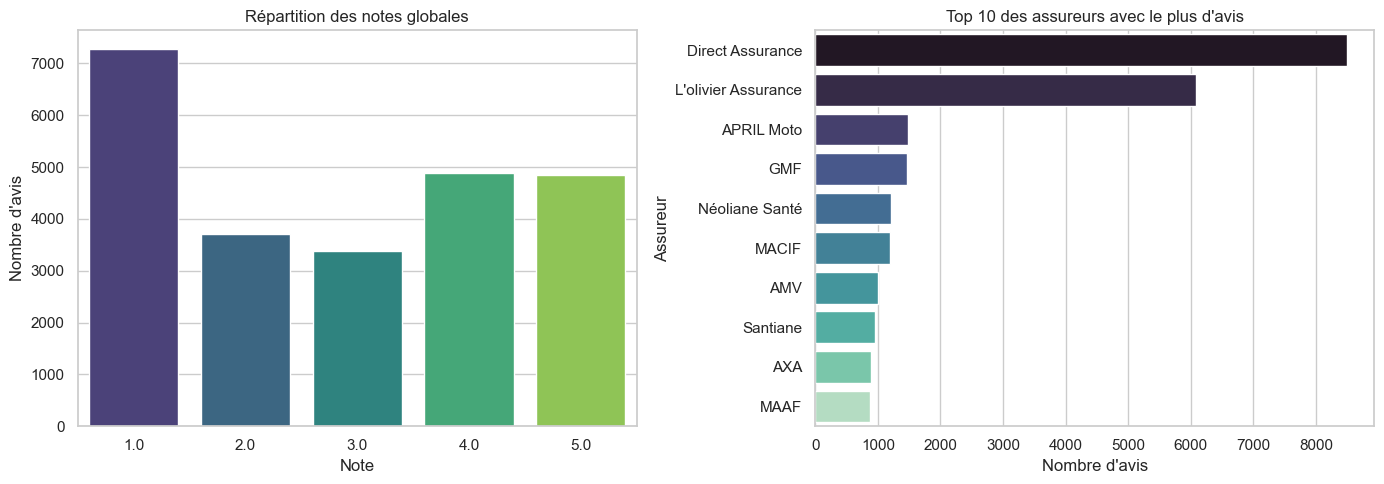

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Style des graphiques
sns.set_theme(style="whitegrid")

plt.figure(figsize=(14, 5))

# Graphique 1 : Répartition des notes (1 à 5)
plt.subplot(1, 2, 1)
sns.countplot(data=df, x='note', palette='viridis')
plt.title('Répartition des notes globales')
plt.xlabel('Note')
plt.ylabel("Nombre d'avis")

# Graphique 2 : Nombre d'avis par assureur (Top 10)
plt.subplot(1, 2, 2)
top_assureurs = df['assureur'].value_counts().head(10)
sns.barplot(y=top_assureurs.index, x=top_assureurs.values, palette='mako')
plt.title('Top 10 des assureurs avec le plus d\'avis')
plt.xlabel("Nombre d'avis")
plt.ylabel('Assureur')

plt.tight_layout()
plt.show()

Plotting Top 15 Words (Unigrams)...


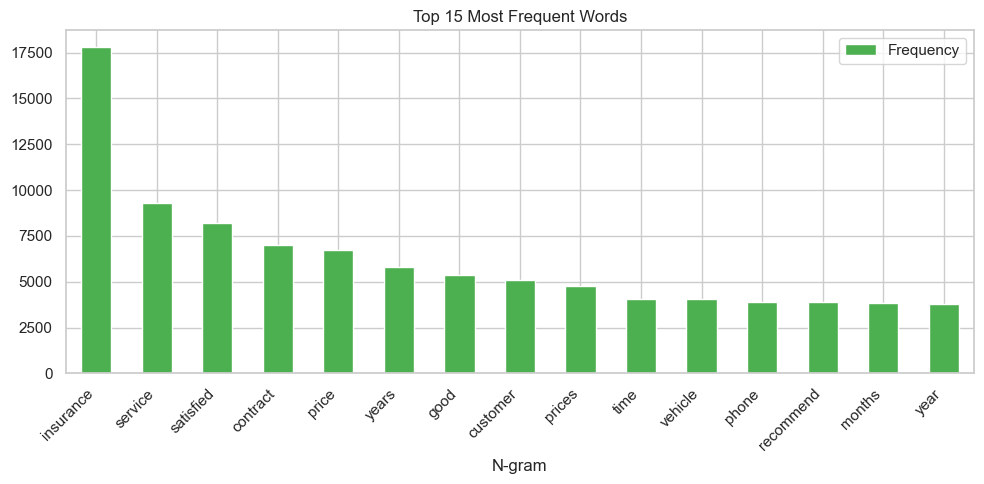

Plotting Top 15 Pairs of Words (Bigrams)...


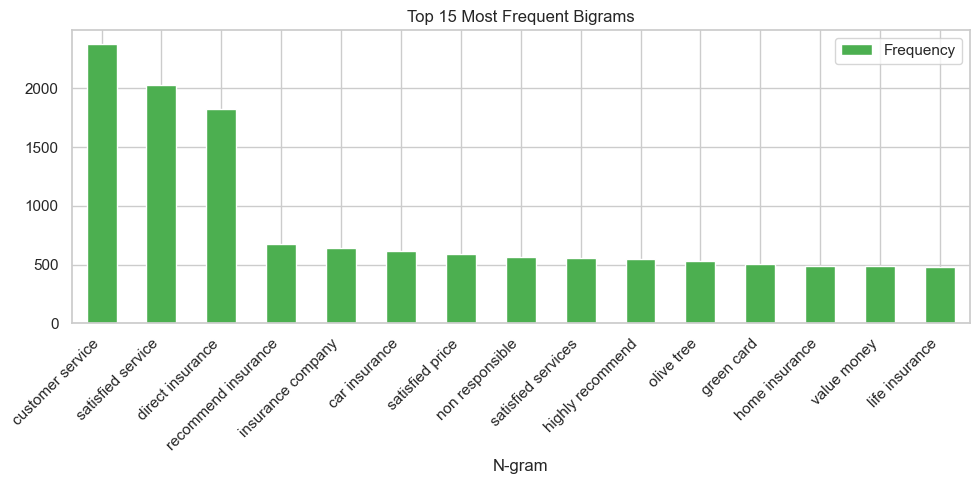

In [7]:
## Basic Cleaning & N-Gram Visualization

import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer

# Drop any rows where the text is completely missing
df_clean = df_master.dropna(subset=['avis_en']).copy()

def plot_ngrams(corpus, n, title, top_k=15):
    # n=1 is unigrams (single words), n=2 is bigrams (two words)
    vec = CountVectorizer(ngram_range=(n, n), stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)[:top_k]
    
    df_freq = pd.DataFrame(words_freq, columns=['N-gram', 'Frequency'])
    df_freq.plot(kind='bar', x='N-gram', y='Frequency', title=title, figsize=(10, 5), color='#4CAF50')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

print("Plotting Top 15 Words (Unigrams)...")
plot_ngrams(df_clean['avis_en'], 1, "Top 15 Most Frequent Words")

print("Plotting Top 15 Pairs of Words (Bigrams)...")
plot_ngrams(df_clean['avis_en'], 2, "Top 15 Most Frequent Bigrams")

In [8]:
!pip install pyspellchecker

In [9]:
import re
import pandas as pd
from spellchecker import SpellChecker
from tqdm import tqdm

# Initialize tqdm for pandas
tqdm.pandas()

print("Loading English spelling dictionary from pyspellchecker")
spell_en = SpellChecker(language='en')

def correct_english_spelling(text):
    if pd.isna(text) or not isinstance(text, str):
        return text
        
    words = spell_en.split_words(text)
    misspelled = spell_en.unknown(words)
    
    corrected_text = text
    for word in misspelled:
        correction = spell_en.correction(word)
        
        if correction and correction != word:
            corrected_text = re.sub(rf'\b{re.escape(word)}\b', correction, corrected_text, flags=re.IGNORECASE)
            
    return corrected_text

print("Applying spelling correction to the first 100 English rows")
df_clean['avis_cor_en'] = df_clean['avis_en'].head(100).progress_apply(correct_english_spelling)

print("\nExample Comparison")
print("Original English:", df_clean['avis_en'].iloc[2])
print("Corrected English:", df_clean['avis_cor_en'].iloc[2])

Loading English spelling dictionary from pyspellchecker
Applying spelling correction to the first 100 English rows


100%|██████████| 100/100 [00:11<00:00,  9.02it/s]


Example Comparison
Original English: Insurer to flee, does not ensure its responsibilities! His insurance agent (SLR FINANCE) from Nice to make false contracts, no support, nothing, forced to make a lawsuit !!
 I will rot them on the web !!
Corrected English: Insurer to flee, does not ensure its responsibilities! His insurance agent (sir FINANCE) from Nice to make false contracts, no support, nothing, forced to make a lawsuit !!
 I will rot them on the web !!


In [10]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

print("Preparing text for Topic Modeling...")
# We use the English reviews ('avis_en') and remove standard stop words
vectorizer = CountVectorizer(max_df=0.95, min_df=2, stop_words='english')
dtm = vectorizer.fit_transform(df_clean['avis_en'].dropna())

print("Training LDA Model to find 5 core topics...")
# We set n_components=5 to find 5 distinct topics
lda_model = LatentDirichletAllocation(n_components=5, random_state=42)
lda_model.fit(dtm)

print("\n--- Discovered Topics ---")
# Display the top 10 words for each topic
for index, topic in enumerate(lda_model.components_):
    print(f"Topic #{index + 1}:")
    # Get the top 10 most heavily weighted words for this topic
    top_words = [vectorizer.get_feature_names_out()[i] for i in topic.argsort()[-10:]]
    print(" ".join(top_words))
    print("-" * 20)

Preparing text for Topic Modeling...
Training LDA Model to find 5 core topics...

--- Discovered Topics ---
Topic #1:
maif disaster euros responsible accident expert car vehicle years insurance
--------------------
Topic #2:
sent service time email phone file months mutual insurance contract
--------------------
Topic #3:
satisfied year years customer service home prices direct price insurance
--------------------
Topic #4:
simple insurance price fast recommend thank prices good service satisfied
--------------------
Topic #5:
online site simple subscription loading insurance contract quote satisfied price
--------------------


In [11]:
import nltk
from nltk.tokenize import word_tokenize
from gensim.models import Word2Vec

# Download the tokenizer package
nltk.download('punkt')
nltk.download('punkt_tab')

print("Tokenizing the reviews for Word2Vec...")
# Word2Vec expects a list of lists (sentences broken into words)
# This might take a minute or two for 34,000 rows!
sentences = [word_tokenize(str(text).lower()) for text in df_clean['avis_en'].dropna()]

print("Training the Word2Vec model...")
# vector_size=100 means each word becomes a 100-dimension vector
w2v_model = Word2Vec(sentences, vector_size=100, window=5, min_count=5, workers=4)

print("Word2Vec Training Complete!\n")

# --- Testing Cosine Distance (Worth 1 Rubric Point) ---
test_word = "insurance"
print(f"Top 5 words most mathematically similar to '{test_word}':")

# .most_similar automatically uses Cosine Distance behind the scenes!
similar_words = w2v_model.wv.most_similar(test_word, topn=5)
for word, similarity_score in similar_words:
    print(f"- {word} (Similarity: {similarity_score:.4f})")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\natha\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\natha\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Tokenizing the reviews for Word2Vec...
Training the Word2Vec model...
Word2Vec Training Complete!

Top 5 words most mathematically similar to 'insurance':
- assurance (Similarity: 0.7227)
- assurances (Similarity: 0.6802)
- debit (Similarity: 0.6297)
- insurer (Similarity: 0.6038)
- debits (Similarity: 0.5986)


Preparing top 100 words for Matplotlib visualization


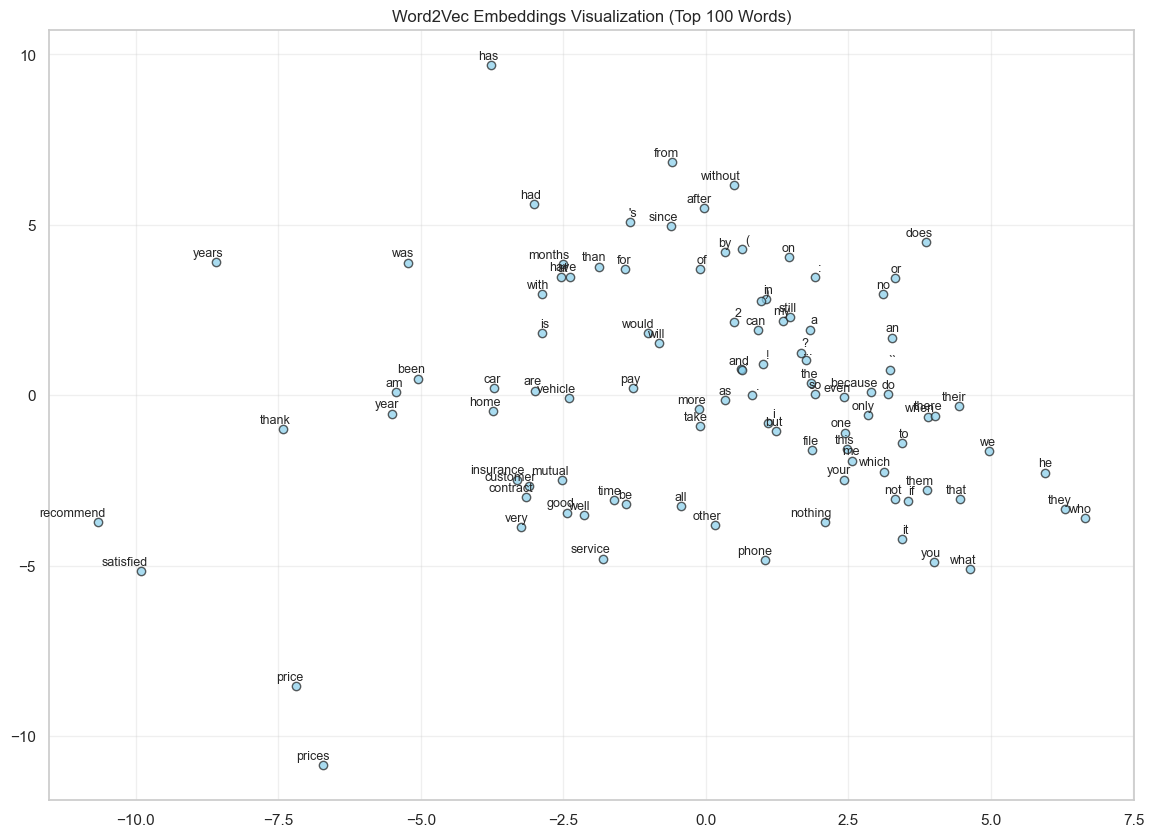

In [12]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np

print("Preparing top 100 words for Matplotlib visualization")

# Extract the top 100 most frequent words and their vectors
words_to_plot = list(w2v_model.wv.index_to_key)[:100]
vectors = np.array([w2v_model.wv[word] for word in words_to_plot])

# Compress from 100 dimensions down to 2
pca = PCA(n_components=2)
vectors_2d = pca.fit_transform(vectors)

# Create the scatter plot
plt.figure(figsize=(14, 10))
plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1], c='skyblue', edgecolors='k', alpha=0.7)

# Add the word labels to each dot
for i, word in enumerate(words_to_plot):
    plt.annotate(word, 
                 xy=(vectors_2d[i, 0], vectors_2d[i, 1]), 
                 xytext=(5, 2), 
                 textcoords='offset points', 
                 ha='right', 
                 va='bottom',
                 fontsize=9)

plt.title("Word2Vec Embeddings Visualization (Top 100 Words)")
plt.grid(True, alpha=0.3)
plt.show()

In [13]:
import os
import torch
from torch.utils.tensorboard import SummaryWriter

print("Exporting top 1000 embeddings to TensorBoard")

# Create a folder for our logs
log_folder = "runs_word2vec"
os.makedirs(log_folder, exist_ok=True)

# Initialize the TensorBoard writer
writer = SummaryWriter(log_folder)

# Extract 1000 words this time for a richer interactive experience
tb_words = list(w2v_model.wv.index_to_key)[:1000]
tb_vectors = np.array([w2v_model.wv[word] for word in tb_words])

# Add the embeddings to TensorBoard
writer.add_embedding(torch.tensor(tb_vectors), metadata=tb_words, tag="Word2Vec_Reviews")
writer.close()

print("Export complete")

Exporting top 1000 embeddings to TensorBoard
Export complete


In [ ]:
from tensorboard import program
import webbrowser

print("Starting TensorBoard local server")
tb = program.TensorBoard()
# Using the Python API avoids needing any terminal arguments entirely
tb.configure(logdir="runs_word2vec")
url = tb.launch()

print(f"Success! TensorBoard is running at {url}")
print("Opening your browser now")
# webbrowser.open(url)
# Select projector in the top right corner of the app to see the word embeddings

Starting TensorBoard local server
Success! TensorBoard is running at http://localhost:6007/
Opening your browser now


True

In [17]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

print("Preparing data for Supervised Learning")
# Ensure we only use rows with both English text and a star rating
df_ml = df_clean.dropna(subset=['avis_en', 'note']).copy()

# Split data: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    df_ml['avis_en'], 
    df_ml['note'], 
    test_size=0.2, 
    random_state=42
)

print("Vectorizing text with TF-IDF")
# We limit to 5000 words to keep the model fast and focused
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Training Classical ML Model (Logistic Regression)")
# max_iter is set to 1000 to ensure the math has enough time to finish
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_tfidf, y_train)

print("Evaluating the model")
predictions = model.predict(X_test_tfidf)
accuracy = accuracy_score(y_test, predictions)

print(f"Baseline TF-IDF Accuracy: {accuracy:.2f}")
print("Classification Report:")
print(classification_report(y_test, predictions))

Preparing data for Supervised Learning
Vectorizing text with TF-IDF
Training Classical ML Model (Logistic Regression)
Evaluating the model
Baseline TF-IDF Accuracy: 0.51
Classification Report:
              precision    recall  f1-score   support

         1.0       0.58      0.89      0.70      1394
         2.0       0.40      0.17      0.23       757
         3.0       0.30      0.16      0.20       657
         4.0       0.45      0.42      0.43      1026
         5.0       0.54      0.58      0.56       987

    accuracy                           0.51      4821
   macro avg       0.45      0.44      0.43      4821
weighted avg       0.48      0.51      0.47      4821



In [18]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from collections import Counter
import numpy as np
from sklearn.metrics import accuracy_score

print("Preparing data for PyTorch Embedding Model")

# PyTorch requires labels to start at 0, so 1 star becomes 0, 5 stars becomes 4
y_train_pt = y_train.values - 1
y_test_pt = y_test.values - 1

# Step 1: Build a vocabulary from our training data
words = " ".join(X_train).split()
vocab = Counter(words)
# Keep only the top 10000 most frequent words to save memory
vocab = {w: i+2 for i, (w, c) in enumerate(vocab.most_common(10000))}
vocab['<PAD>'] = 0  # Padding for short reviews
vocab['<UNK>'] = 1  # Unknown words

def encode_text(text, max_len=100):
    tokens = str(text).split()
    # Convert words to numbers, use 1 for unknown words
    encoded = [vocab.get(w, 1) for w in tokens][:max_len]
    # Pad with 0s if the review is shorter than max_len
    if len(encoded) < max_len:
        encoded += [0] * (max_len - len(encoded))
    return encoded

print("Encoding text sequences into numbers")
X_train_pt = np.array([encode_text(text) for text in X_train])
X_test_pt = np.array([encode_text(text) for text in X_test])

# Step 2: Create the PyTorch Dataset class
class ReviewDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(ReviewDataset(X_train_pt, y_train_pt), batch_size=32, shuffle=True)
test_loader = DataLoader(ReviewDataset(X_test_pt, y_test_pt), batch_size=32)

# Step 3: Define the Neural Network Architecture
class BasicEmbeddingModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_classes):
        super().__init__()
        # The Embedding layer learns the mathematical relationship between words
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.fc1 = nn.Linear(embed_dim, 64)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(64, num_classes)
        
    def forward(self, x):
        embedded = self.embedding(x)
        # Average the word vectors across the entire review
        pooled = embedded.mean(dim=1)
        out = self.relu(self.fc1(pooled))
        out = self.fc2(out)
        return out

print("Initializing the PyTorch Model")
model_emb = BasicEmbeddingModel(vocab_size=len(vocab)+2, embed_dim=50, num_classes=5)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_emb.parameters(), lr=0.005)

print("Starting training loop")
epochs = 5
for epoch in range(epochs):
    model_emb.train()
    total_loss = 0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        predictions = model_emb(batch_X)
        loss = criterion(predictions, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        
    print(f"Epoch {epoch+1} completed with Average Loss: {total_loss/len(train_loader):.4f}")

print("Evaluating the PyTorch model on the test set")
model_emb.eval()
all_preds = []
with torch.no_grad():
    for batch_X, _ in test_loader:
        outputs = model_emb(batch_X)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.numpy())

accuracy_pt = accuracy_score(y_test_pt, all_preds)
print(f"PyTorch Embedding Model Accuracy: {accuracy_pt:.2f}")

Preparing data for PyTorch Embedding Model
Encoding text sequences into numbers
Initializing the PyTorch Model
Starting training loop
Epoch 1 completed with Average Loss: 1.2334
Epoch 2 completed with Average Loss: 1.0829
Epoch 3 completed with Average Loss: 1.0132
Epoch 4 completed with Average Loss: 0.9293
Epoch 5 completed with Average Loss: 0.8461
Evaluating the PyTorch model on the test set
PyTorch Embedding Model Accuracy: 0.49


In [19]:
print("Building pre-trained embedding matrix")

# Create an empty matrix for our vocabulary
# We use 100 dimensions because that is what we trained our Word2Vec model on earlier
embedding_matrix = np.zeros((len(vocab) + 2, 100))

# Fill the PyTorch matrix with our Word2Vec weights
words_found = 0
for word, i in vocab.items():
    if word in w2v_model.wv:
        embedding_matrix[i] = w2v_model.wv[word]
        words_found += 1

print(f"Loaded {words_found} pre-trained Word2Vec vectors into PyTorch")

# Define the new architecture using the pre-trained weights
class PreTrainedEmbeddingModel(nn.Module):
    def __init__(self, embedding_matrix, num_classes):
        super().__init__()
        # Load the pre-trained weights and allow them to fine-tune (freeze=False)
        weights = torch.FloatTensor(embedding_matrix)
        self.embedding = nn.Embedding.from_pretrained(weights, freeze=False)
        self.fc1 = nn.Linear(100, 64)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(64, num_classes)
        
    def forward(self, x):
        embedded = self.embedding(x)
        pooled = embedded.mean(dim=1)
        out = self.relu(self.fc1(pooled))
        out = self.fc2(out)
        return out

print("Initializing the Pre-trained Model")
model_pretrained = PreTrainedEmbeddingModel(embedding_matrix, num_classes=5)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_pretrained.parameters(), lr=0.005)

print("Starting training loop for Pre-trained Model")
epochs = 5
for epoch in range(epochs):
    model_pretrained.train()
    total_loss = 0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        predictions = model_pretrained(batch_X)
        loss = criterion(predictions, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        
    print(f"Epoch {epoch+1} completed with Average Loss: {total_loss/len(train_loader):.4f}")

print("Evaluating the Pre-trained model on the test set")
model_pretrained.eval()
all_preds_pre = []
with torch.no_grad():
    for batch_X, _ in test_loader:
        outputs = model_pretrained(batch_X)
        _, predicted = torch.max(outputs, 1)
        all_preds_pre.extend(predicted.numpy())

accuracy_pre = accuracy_score(y_test_pt, all_preds_pre)
print(f"Pre-Trained Model Accuracy: {accuracy_pre:.2f}")

Building pre-trained embedding matrix
Loaded 5456 pre-trained Word2Vec vectors into PyTorch
Initializing the Pre-trained Model
Starting training loop for Pre-trained Model
Epoch 1 completed with Average Loss: 1.1427
Epoch 2 completed with Average Loss: 1.0210
Epoch 3 completed with Average Loss: 0.9236
Epoch 4 completed with Average Loss: 0.8094
Epoch 5 completed with Average Loss: 0.6921
Evaluating the Pre-trained model on the test set
Pre-Trained Model Accuracy: 0.47


In [22]:
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
from torch.optim import AdamW

print("Loading Hugging Face Tokenizer")
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

print("Subsampling data so your CPU can handle it")
# We take a random sample of 2000 rows for training and 500 for testing
X_train_sub = X_train.sample(n=5000, random_state=42)
y_train_sub = y_train.loc[X_train_sub.index].values - 1

X_test_sub = X_test.sample(n=500, random_state=42)
y_test_sub = y_test.loc[X_test_sub.index].values - 1

class TransformerDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts.tolist()
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )
        
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

print("Preparing DataLoaders")
train_dataset = TransformerDataset(X_train_sub, y_train_sub, tokenizer)
test_dataset = TransformerDataset(X_test_sub, y_test_sub, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16)

print("Downloading and Initializing DistilBERT Model")
model_bert = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased', 
    num_labels=5
)

# We use AdamW, which is the standard optimizer for Hugging Face transformers
optimizer = AdamW(model_bert.parameters(), lr=5e-5)

print("Starting DistilBERT Training for 2 Epochs")
epochs = 3

for epoch in range(epochs):
    model_bert.train()
    total_loss = 0
    
    print(f"Beginning Epoch {epoch + 1}")
    
    for batch_idx, batch in enumerate(train_loader):
        optimizer.zero_grad()
        
        input_ids = batch['input_ids']
        attention_mask = batch['attention_mask']
        labels = batch['labels']
        
        outputs = model_bert(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        
        if batch_idx % 25 == 0 and batch_idx > 0:
            print(f"Epoch {epoch + 1} | Batch {batch_idx} completed")

    print(f"Epoch {epoch + 1} completed with Average Loss: {total_loss/len(train_loader):.4f}")

print("Evaluating DistilBERT on the test set")
model_bert.eval()
all_preds_bert = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids']
        attention_mask = batch['attention_mask']
        
        outputs = model_bert(input_ids=input_ids, attention_mask=attention_mask)
        _, predicted = torch.max(outputs.logits, 1)
        all_preds_bert.extend(predicted.numpy())

accuracy_bert = accuracy_score(y_test_sub, all_preds_bert)
print(f"DistilBERT Accuracy: {accuracy_bert:.2f}")

Loading Hugging Face Tokenizer
Subsampling data so your CPU can handle it
Preparing DataLoaders


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 5726.32it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Starting DistilBERT Training for 2 Epochs
Beginning Epoch 1
Epoch 1 | Batch 25 completed
Epoch 1 | Batch 50 completed
Epoch 1 | Batch 75 completed
Epoch 1 | Batch 100 completed
Epoch 1 | Batch 125 completed
Epoch 1 | Batch 150 completed
Epoch 1 | Batch 175 completed
Epoch 1 | Batch 200 completed
Epoch 1 | Batch 225 completed
Epoch 1 | Batch 250 completed
Epoch 1 | Batch 275 completed
Epoch 1 | Batch 300 completed
Epoch 1 completed with Average Loss: 1.1578
Beginning Epoch 2
Epoch 2 | Batch 25 completed
Epoch 2 | Batch 50 completed
Epoch 2 | Batch 75 completed
Epoch 2 | Batch 100 completed
Epoch 2 | Batch 125 completed
Epoch 2 | Batch 150 completed
Epoch 2 | Batch 175 completed
Epoch 2 | Batch 200 completed
Epoch 2 | Batch 225 completed
Epoch 2 | Batch 250 completed
Epoch 2 | Batch 275 completed
Epoch 2 | Batch 300 completed
Epoch 2 completed with Average Loss: 1.0025
Beginning Epoch 3
Epoch 3 | Batch 25 completed
Epoch 3 | Batch 50 completed
Epoch 3 | Batch 75 completed
Epoch 3 | Batch

In [23]:
import joblib

print("Saving the TF-IDF vectorizer and Logistic Regression model")
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')
joblib.dump(model, 'logistic_model.pkl')
print("Files successfully saved for Streamlit")

Saving the TF-IDF vectorizer and Logistic Regression model
Files successfully saved for Streamlit
